**MVP**

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('ground_station.csv')
df.columns = df.columns.str.strip()

print(df.isnull().sum())

df.head()

Name              0
Organization      0
Type              0
Location          0
Latitude          6
Longitude         6
Bands           287
Antenna           9
dtype: int64


,Name,Organization,Type,Location,Latitude,Longitude,Bands,Antenna
0,Cebreros Station (CEB1),ESA,Space Agency,"Cebreros, Spain",40.453475,-4.368266,"S, X",Parabolic Dish
1,UVG Ground Station,Universidad del Valle de Guatemala,University,"Guatemala City, Guatemala",14.603762,-90.489248,NaN,Unknown
2,Auckland,INMARSAT,Company,"Auckland, New Zealand",-36.850883,174.764488,"L, Ka",Parabolic Dish
3,National Institute for Space Research (INPE) G...,INPE,Government Institution,"Cuiabá, Mato Grosso, Brazil",-15.595463,-56.092582,"S, X",Various
4,AITEX Ground Station,AITEX (Textile Industry Research Association),Research Institution,"Alcoy, Valencian Community, Spain",38.689848,-0.496591,NaN,Unknown


In [ ]:
#trying to see how many how many satellites are most likely high level infrastructure
df['Type'].value_counts()

Type
Company                                                                         332
University                                                                      203
Space Agency                                                                     67
Research Institution                                                             36
Government Institution                                                           19
Other                                                                             4
<span data-type="intl_org" class="sc-fTmHRu eFxvc"International Organization      4
Name: count, dtype: int64

In [ ]:
#did some very basic research and X, Ka, Ku, Q, V, EHF need
df['Bands'].value_counts()

Bands
S, X                  94
L, S, X               27
S, X, Ka              25
UHF, L, S, X          23
C, Ku, Ka             22
Ka                    22
S                     19
L, Ka                 16
X                     16
UHF, S, X             15
X, S                   8
C, Ku                  8
S, Ka                  8
UHF, S                 7
Ku, Ka                 6
UHF, VHF               5
Ku                     4
VHF, UHF               4
UHF                    4
S, X, C                3
L, S, X, Ka            3
L                      2
S, X, Ku               2
X, Ka                  2
L, X                   2
VHF, UHF, S            2
LEO                    2
VHF, UHF, S-band       2
S, X, L                2
S, UHF, VHF            2
S, X, SGLS             1
S, C, Ka               1
UHF, VHF, L, S         1
Ka, Ku, C              1
UHF/VHF, S, X          1
VHF, UHF, C            1
Optical                1
L, C, Ku, X, Ka, V     1
UHF, VHF, S            1
C, X, Ku           

In [ ]:
df['Antenna'].value_counts()

Antenna
Parabolic Dish        210
Unknown               122
unknown                48
KSAT Antenna           42
LeafSpace Antenna      25
                     ... 
Tracking Telescope      1
UHF/VHF                 1
VSAT                    1
S/X-band                1
Polarized Antenna       1
Name: count, Length: 105, dtype: int64

In [8]:
# 1. Define our scoring keywords
high_freqs = ['S', 'X', 'Ka', 'Ku', 'Assumed']
heavy_antennas = ['Parabolic', 'Dish', 'KSAT', 'LeafSpace', 'Array', 'Assumed']
gov_types = ['Space Agency', 'Government Institution', 'Research Institution', 'International Organization']

# 2. Vectorized scoring function
def quick_categorize(row):
    score = 0
    band_str = str(row['Bands']).upper()
    antenna_str = str(row['Antenna']).upper()
    type_str = str(row['Type'])
    
    # Check for strict UHF/VHF low-power override
    # If bands are populated but contain NO high frequencies, drop to Low immediately
    if pd.notna(row['Bands']) and not any(f in band_str for f in high_freqs):
        if any(low in band_str for low in ['UHF', 'VHF']):
            return 'Prob Not (Low-Power Noise)'

    # Accumulate Points
    if type_str in gov_types:
        score += 2
    elif type_str in ['Company', 'University']:
        score += 1
        
    if any(f in band_str for f in high_freqs):
        score += 2
        
    if any(a in antenna_str for a in heavy_antennas):
        score += 2
        
    # Classify based on score threshold
    # A score of 3 or higher means it has at least one confirmed heavy asset + a valid type
    return 'Prob High Level' if score >= 3 else 'Prob Not'

# 3. Apply instantly to your dataframe
df['Probability_Class'] = df.apply(quick_categorize, axis=1)

# 4. Print your MVP results summary
print("--- MVP Classification Breakdown ---")
print(df['Probability_Class'].value_counts())

# View a quick preview of your high-probability proxy targets
df[df['Probability_Class'] == 'Prob High Level'][['Name', 'Type', 'Bands', 'Antenna']].head()

--- MVP Classification Breakdown ---
Probability_Class
Prob Not                      379
Prob High Level               272
Prob Not (Low-Power Noise)     14
Name: count, dtype: int64


,Name,Type,Bands,Antenna
0,Cebreros Station (CEB1),Space Agency,"S, X",Parabolic Dish
3,National Institute for Space Research (INPE) G...,Government Institution,"S, X",Various
6,SSC - Clewiston Satellite Station,Company,"S, X",SSC Antenna
13,SSC - Esrange Space Center Satellite Station,Company,"UHF, S, X","Multiple S-Band TT&C, S/X-Band Receive"
14,Satellite Applications Catapult Goonhilly Grou...,Research Institution,"S, X, Ka",Parabolic Dish


In [9]:
# Replace common string variations of missing data with actual NaNs
null_variants = ['unknown', 'Unknown', 'N/A', 'NaN', 'none', 'None', 'unspecified']
df = df.replace(null_variants, np.nan)

# ==========================================
# STEP 2: IMPUTATION & STANDARDIZATION
# ==========================================
print("2. Imputing space agency data and standardizing commercial antennas...")
# Impute missing values for verified space agencies
major_agencies = ['NASA', 'ESA', 'ISRO', 'JAXA', 'CNES', 'DLR', 'CNSA']
agency_mask = (df['Organization'].isin(major_agencies)) | (df['Type'] == 'Space Agency')

df.loc[agency_mask & df['Bands'].isna(), 'Bands'] = 'S/X-Assumed'
df.loc[agency_mask & df['Antenna'].isna(), 'Antenna'] = 'Parabolic-Assumed'

# Standardize high-infrastructure commercial antennas
commercial_heavy_infra = ['KSAT Antenna', 'LeafSpace Antenna']
def standardize_antennas(val):
    if pd.isna(val):
        return val
    if val in commercial_heavy_infra:
        return 'Parabolic-GSaaS'
    return val

df['Antenna'] = df['Antenna'].apply(standardize_antennas)

# ==========================================
# STEP 3: CLASSIFICATION MATRiX
# ==========================================
print("3. Executing infrastructure classification scoring...")
high_freqs = ['S', 'X', 'KA', 'KU', 'ASSUMED']
heavy_antennas = ['PARABOLIC', 'DISH', 'GSAAS', 'ARRAY', 'ASSUMED']
gov_types = ['Space Agency', 'Government Institution', 'Research Institution', 'International Organization']

def categorize_infrastructure(row):
    score = 0
    band_str = str(row['Bands']).upper()
    antenna_str = str(row['Antenna']).upper()
    type_str = str(row['Type'])
    
    # Strict Override: If bands are listed but contain NO high frequencies, drop to Low immediately
    if pd.notna(row['Bands']) and not any(f in band_str for f in high_freqs):
        if any(low in band_str for low in ['UHF', 'VHF']):
            return 'Prob Not'

    # Points Assignment
    if type_str in gov_types:
        score += 2
    elif type_str in ['Company', 'University']:
        score += 1
        
    if any(f in band_str for f in high_freqs):
        score += 2
        
    if any(a in antenna_str for a in heavy_antennas):
        score += 2
        
    # Threshold classification
    return 'Prob High Level' if score >= 3 else 'Prob Not'

df['Probability_Class'] = df.apply(categorize_infrastructure, axis=1)

# ==========================================
# STEP 4: FILTER AND SPATIAL EXPORT
# ==========================================
print("4. Filtering targets and generating GeoPackage...")
# Keep only the high probability infrastructure targets
high_prob_df = df[df['Probability_Class'] == 'Prob High Level'].copy()

# Drop rows missing coordinates (cannot be mapped)
final_spatial_df = high_prob_df.dropna(subset=['Latitude', 'Longitude']).copy()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    final_spatial_df, 
    geometry=gpd.points_from_xy(final_spatial_df['Longitude'], final_spatial_df['Latitude']), 
    crs="EPSG:4326"
)

# Save to disk
output_file = 'high_infra_proxy_stations.gpkg'
gdf.to_file(output_file, driver='GPKG', layer='ground_stations')

print("\n=== PIPELINE COMPLETE ===")
print(f"Original Dataset Size: {len(df)} rows")
print(f"Filtered High-Probability Targets: {len(high_prob_df)} rows")
print(f"Final Mappable Points Exported: {len(gdf)} points")
print(f"File saved as: {output_file} - Ready for QGIS!")

2. Imputing space agency data and standardizing commercial antennas...
3. Executing infrastructure classification scoring...
4. Filtering targets and generating GeoPackage...

=== PIPELINE COMPLETE ===
Original Dataset Size: 665 rows
Filtered High-Probability Targets: 426 rows
Final Mappable Points Exported: 421 points
File saved as: high_infra_proxy_stations.gpkg - Ready for QGIS!


Success: 'high_infra_proxy_stations.gpkg' was found on disk!

Total points loaded: 421
Sample of the exported data:


,Name,Type,Bands,Antenna,Probability_Class
0,Cebreros Station (CEB1),Space Agency,"S, X",Parabolic Dish,Prob High Level
1,Auckland,Company,"L, Ka",Parabolic Dish,Prob High Level
2,National Institute for Space Research (INPE) G...,Government Institution,"S, X",Various,Prob High Level
3,SSC - Clewiston Satellite Station,Company,"S, X",SSC Antenna,Prob High Level
4,Rambouillet Teleport,Company,"C, Ku, Ka",Parabolic Dish,Prob High Level



Generating quick map preview...


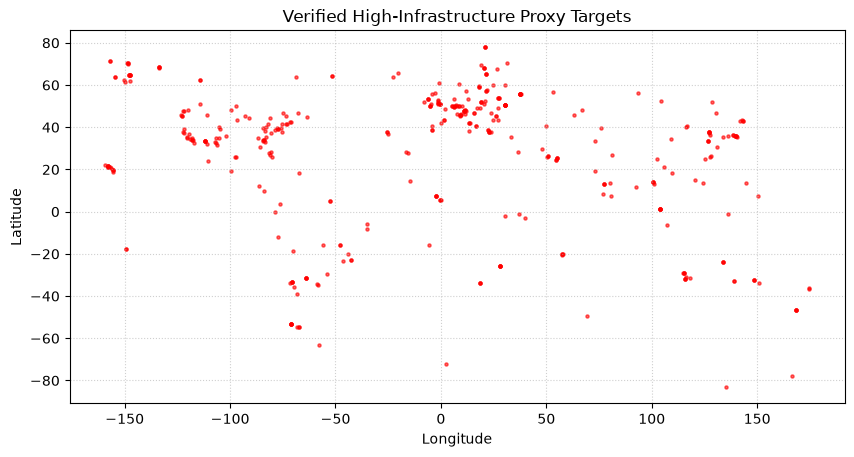

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

file_path = 'high_infra_proxy_stations.gpkg'

# 1. Verify the file exists on disk
if os.path.exists(file_path):
    print(f"Success: '{file_path}' was found on disk!\n")
    
    # 2. Load the spatial data back into a GeoDataFrame
    test_gdf = gpd.read_file(file_path, layer='ground_stations')
    
    # 3. Print a quick sanity check of the data
    print(f"Total points loaded: {len(test_gdf)}")
    print("Sample of the exported data:")
    display(test_gdf[['Name', 'Type', 'Bands', 'Antenna', 'Probability_Class']].head())
    
    # 4. Generate a quick spatial plot to verify coordinates
    print("\nGenerating quick map preview...")
    fig, ax = plt.subplots(figsize=(10, 5))
    test_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.6)
    
    # Add some basic styling
    ax.set_title('Verified High-Infrastructure Proxy Targets')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

else:
    print(f" Error: '{file_path}' not found. Check if the previous cell finished running.")